# Authors

- David Robredo Manuel
- Duarte Novas Álvarez
- Rubén González Braña

## Imports

In [48]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from keras.callbacks import EarlyStopping
from keras.utils import to_categorical

import os

## Functions

In [49]:
def show_image(image):

    plt.imshow(image)
    plt.axis("off")
    plt.show()

## Preprocessing

#### LOADING DATA

In [50]:
import os
import cv2
import numpy as np

# Ruta al dataset
dataset_path = 'dataset'

# Listas para las imágenes y etiquetas
X = []
y = []

# Tamaño al que redimensionar las imágenes (puedes cambiarlo)
img_size = (224, 224)  # ancho x alto

# Recorrer las carpetas
for label in os.listdir(dataset_path):
    print(f"Procesando {label}")

    label_path = os.path.join(dataset_path, label)
    if os.path.isdir(label_path):  # Asegurarse de que es una carpeta
        for file_name in os.listdir(label_path):
            file_path = os.path.join(label_path, file_name)
            # Leer la imagen con cv2
            img = cv2.imread(file_path)
            if img is not None:  # Verificar que la imagen se leyó correctamente
                # Convertir de BGR a RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                # Redimensionar la imagen
                img = cv2.resize(img, img_size)
                # Añadir a las listas
                X.append(img)
                y.append(label)
            else:
                print(f"Error al leer la imagen: {file_path}")
        

# Convertir a arrays de numpy
X = np.array(X)
y = np.array(y)

print(f"Total de imágenes cargadas: {len(X)}")
print(f"Etiquetas únicas: {set(y)}")

Procesando Acitinic Keratosis
Procesando Basal Cell Carcinoma
Procesando Dermatofibroma
Error al leer la imagen: dataset\Dermatofibroma\metadata.csv
Procesando Melanoma
Total de imágenes cargadas: 1904
Etiquetas únicas: {'Acitinic Keratosis', 'Melanoma', 'Dermatofibroma', 'Basal Cell Carcinoma'}


In [51]:
from keras.utils import to_categorical

In [52]:
y = pd.get_dummies(y)

#### TRAINING AND TEST SETS

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [55]:
len(X_train), len(X_test), len(y_train), len(y_test)

(1275, 629, 1275, 629)

## Models

### Model 1

#### Creation

We define an augmentation layer that will increase artificially the number of input images, to avoid overfitting, with a random rotation and zoom

In [56]:
data_augmentation_layer_1 = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.1),
        keras.layers.RandomZoom(0.2),
    ]
)

Then we define the architecture of the first model, with a rescaling layer to put all the pixel values in the range [0,1], several convolutional layers, a pooling layer and the a flatten layer. Finally, we apply dropout in order to avoid overfitting. The ouput layer is a Dense layer with 20 units, because we have 20 output classes.

In [57]:
inputs = keras.Input(shape=(224, 224, 3, ))

x = data_augmentation_layer_1(inputs)

x = keras.layers.Rescaling(1./255)(x)
x = keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = keras.layers.MaxPooling2D(pool_size=2)(x)
x = keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = keras.layers.MaxPooling2D(pool_size=2)(x)
x = keras.layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dropout(0.4)(x)

outputs = keras.layers.Dense(4, activation="softmax")(x)
model_1 = keras.Model(inputs = inputs, outputs = outputs)
model_1.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 sequential_2 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 rescaling_3 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 conv2d_9 (Conv2D)           (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 111, 111, 32)     0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 109, 109, 64)      18496     
                                                           

#### Compilation

We use the adam optimizer because of its adaptation to the situation

In [58]:
model_1.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics = ["accuracy"]
)

#### Tranining

We define an early stopping callback so we can end the training when the "val_loss" has not been increased in 15 epochs

In [59]:
early_stopping_cb = EarlyStopping(patience=15, monitor="val_loss", mode="min", restore_best_weights=True)

We define a validation set of 20% of the total data

In [60]:
history_model_1 = model_1.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    callbacks=[early_stopping_cb]
)

Epoch 1/200
32/32 [==============================] - 43s 1s/step - loss: 1.8406 - accuracy: 0.3206 - val_loss: 1.3090 - val_accuracy: 0.3804
Epoch 2/200
32/32 [==============================] - 38s 1s/step - loss: 1.1847 - accuracy: 0.4490 - val_loss: 1.2654 - val_accuracy: 0.3765
Epoch 3/200
32/32 [==============================] - 39s 1s/step - loss: 1.1636 - accuracy: 0.4657 - val_loss: 1.2688 - val_accuracy: 0.4353
Epoch 4/200
32/32 [==============================] - 39s 1s/step - loss: 1.1387 - accuracy: 0.4863 - val_loss: 1.2380 - val_accuracy: 0.4824
Epoch 5/200
32/32 [==============================] - 40s 1s/step - loss: 1.1497 - accuracy: 0.4745 - val_loss: 1.2350 - val_accuracy: 0.4941
Epoch 6/200
32/32 [==============================] - 40s 1s/step - loss: 1.0887 - accuracy: 0.4873 - val_loss: 1.3694 - val_accuracy: 0.4471
Epoch 7/200
32/32 [==============================] - 37s 1s/step - loss: 1.0885 - accuracy: 0.5127 - val_loss: 1.1597 - val_accuracy: 0.4588
Epoch 8/200
3

In [61]:
model_1.save("Model1.h5")

<Axes: >

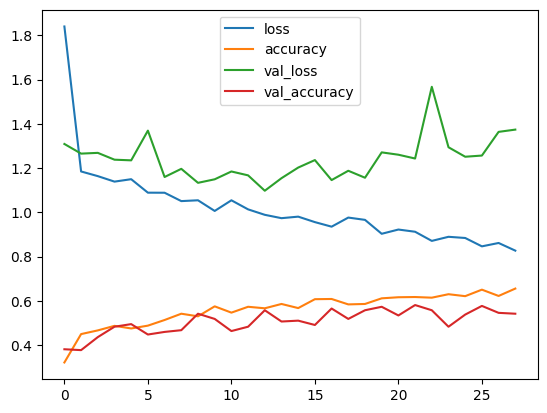

In [62]:
pd.DataFrame(history_model_1.history).to_csv("Model1_Train_History.csv")
pd.DataFrame(history_model_1.history).plot()

#### Testing

Finally, we test the model with data that it has never seen

In [63]:
model_1.evaluate(X_test, y_test)

20/20 [==============================] - 4s 213ms/step - loss: 1.0591 - accuracy: 0.5405


[1.059145450592041, 0.5405405163764954]

---